# The EDA Methodology & Data Profiling
## 💡 Concept: Disciplined Investigation

Exploratory Data Analysis is not random plotting; it is a disciplined, systematic investigation. Before asking complex questions, you must map out the characteristics and "shape" of your data:

- Univariate Analysis 📈: Evaluating variables one at a time to understand their distribution, central tendency (mean/median), and spread (variance/standard deviation).

- Bivariate Analysis 🔗: Investigating directional relationships and dependencies between two distinct variables.

- Outlier Detection 🚨: Isolating extreme data points that deviate significantly from standard operating behavior—these could indicate collection errors or critical real-world events.

- Missing Data Fingerprinting 🔍: Analyzing the patterns behind missing information to determine if gaps are completely random or systematic.


## 🛠️ Applied Activity: Profiling the Depot Performance Dataset

We will simulate an operational logistics dataset spanning four major Kenyan distribution hubs. One of these depots contains a hidden bottleneck. We will run a data profiling health check and build univariate and outlier charts to track down the issue.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Establish standardized styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



In [3]:
# --- SIMULATING THE PRODUCTION DATA STREAM ---
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=100, freq='D')
depots = ['Mombasa', 'Nairobi', 'Kisumu', 'Eldoret']
data = []

for date in dates:
    for depot in depots:
        base_throughput = np.random.normal(1000, 100)
        
        # HIDDEN STRUCTURAL FAILURE: Nairobi hits a severe bottleneck after Feb 1st
        if depot == 'Nairobi' and date > pd.Timestamp('2026-02-01'):
            base_throughput *= 0.6  # 40% structural drop
            
        throughput = max(0, base_throughput + np.random.normal(0, 50))
        data.append({
            'date': date,
            'depot': depot,
            'throughput_bbl': throughput,
            'temperature_c': np.random.normal(25, 5),
            'maintenance_flag': np.random.choice([0, 1], p=[0.95, 0.05])
        })

df_eda = pd.DataFrame(data)



In [4]:
# Structural Profiling Health Check
print("=== Structural Data Profile ===")
print(df_eda.describe())
print("\n=== Missing Data Audit ===")
print(df_eda.isnull().sum())



=== Structural Data Profile ===
                      date  throughput_bbl  temperature_c  maintenance_flag
count                  400      400.000000     400.000000        400.000000
mean   2026-02-19 12:00:00      927.657137      25.543576          0.062500
min    2026-01-01 00:00:00      423.022578      11.295226          0.000000
25%    2026-01-25 18:00:00      852.886473      22.184346          0.000000
50%    2026-02-19 12:00:00      962.911783      25.559517          0.000000
75%    2026-03-16 06:00:00     1050.702460      28.889034          0.000000
max    2026-04-10 00:00:00     1451.817215      40.394404          1.000000
std                    NaN      188.189077       4.876250          0.242365

=== Missing Data Audit ===
date                0
depot               0
throughput_bbl      0
temperature_c       0
maintenance_flag    0
dtype: int64


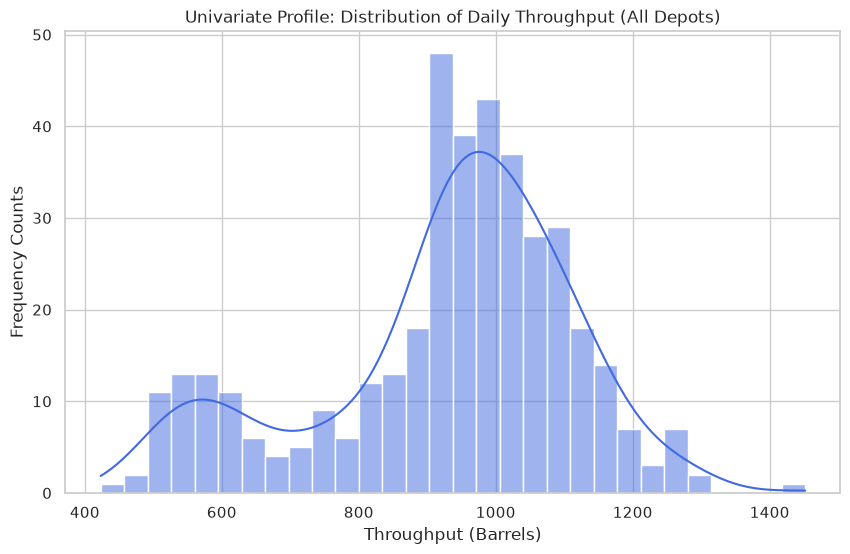

In [5]:
# Univariate Analysis: Throughput Distribution Shape
plt.figure()
sns.histplot(df_eda['throughput_bbl'], kde=True, bins=30, color='royalblue')
plt.title('Univariate Profile: Distribution of Daily Throughput (All Depots)')
plt.xlabel('Throughput (Barrels)')
plt.ylabel('Frequency Counts')
plt.show()



/tmp/ipykernel_1231200/3180420777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depot', y='throughput_bbl', data=df_eda, palette='Set2')


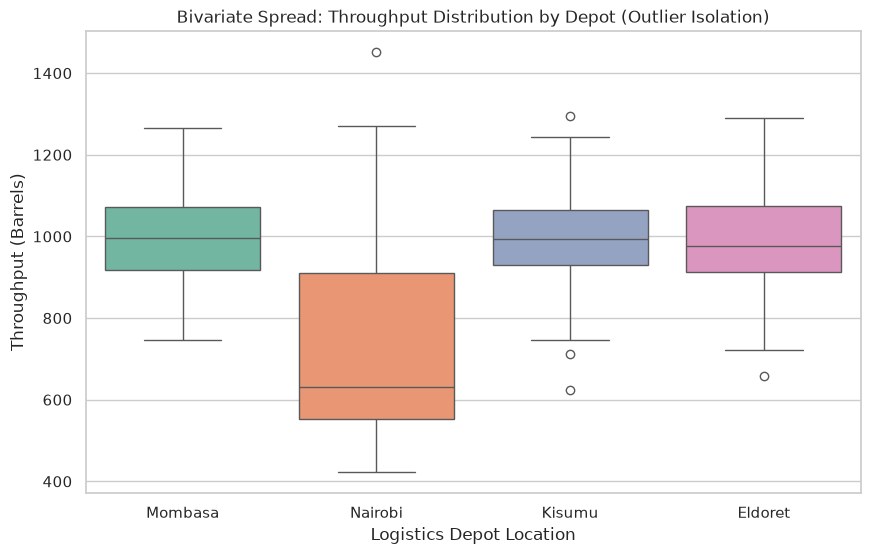

In [6]:
# Outlier and Spread Analysis via Boxplots
plt.figure()
sns.boxplot(x='depot', y='throughput_bbl', data=df_eda, palette='Set2')
plt.title('Bivariate Spread: Throughput Distribution by Depot (Outlier Isolation)')
plt.xlabel('Logistics Depot Location')
plt.ylabel('Throughput (Barrels)')
plt.show()



In [7]:
# Interactive Deep-Dive Exploration with Plotly
fig = px.box(df_eda, x='depot', y='throughput_bbl', color='depot',
             title='Interactive Diagnostic Portal: Throughput Metrics by Depot Location')
fig.show()

# Correlation & Relationship Analysis
## 💡 Concept: Mapping Dependencies

Operational systems are driven by interconnected variables. To optimize a process, you must measure how different factors influence one another.

- Correlation Matrix 🧮: A grid that calculates the Pearson correlation coefficient ($r$) between numerical columns, ranging from $-1.0$ (perfect inverse relationship) to $+1.0$ (perfect positive relationship).

- Scatter Plots 🛰️: Visual layouts used to quickly identify linear trends, non-linear patterns, and clustering behaviors.

- Confounding Variables 🎭: A common analytical trap where two variables appear to have a direct relationship, but are actually both being driven by a hidden third factor. Always remember: Correlation does not equal Causation!


## 🛠️ Applied Activity: Diagnosing the Throughput Drop

We will run a correlation matrix across our telemetry attributes and construct a time-series decomposition to determine if our throughput issue is tied to environmental temperatures, maintenance schedules, or localized structural breaks.

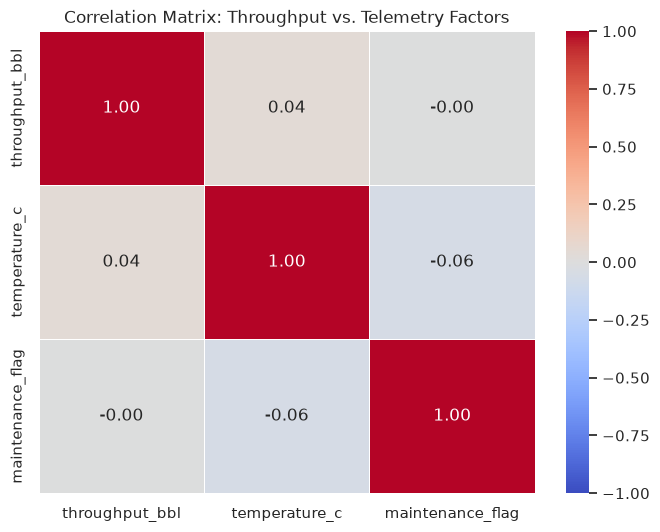

In [8]:
# --- MODULE 2: CORRELATION & RELATIONSHIP ANALYSIS ---

# Heatmap Analysis of the Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_df = df_eda[['throughput_bbl', 'temperature_c', 'maintenance_flag']]
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Throughput vs. Telemetry Factors')
plt.show()



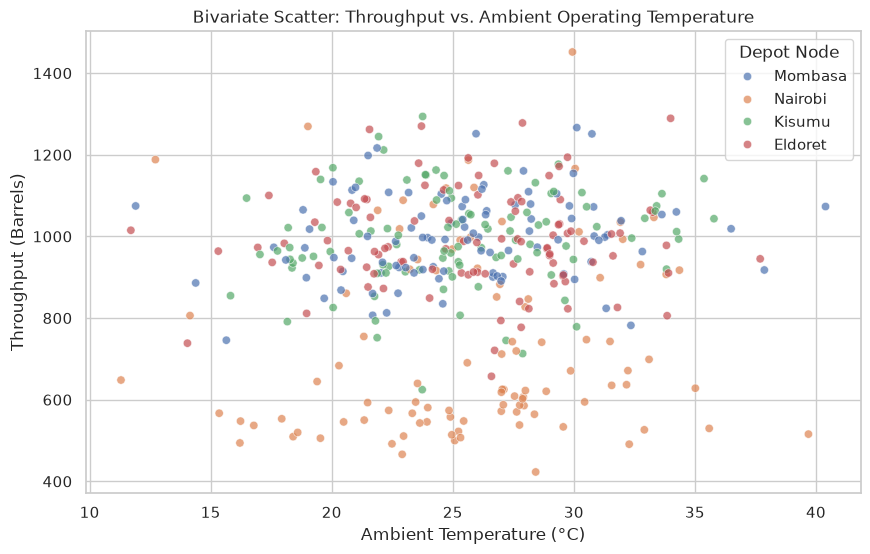

In [9]:
# Bivariate Scatter Analysis
plt.figure()
sns.scatterplot(x='temperature_c', y='throughput_bbl', hue='depot', data=df_eda, alpha=0.7)
plt.title('Bivariate Scatter: Throughput vs. Ambient Operating Temperature')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Throughput (Barrels)')
plt.legend(title='Depot Node')
plt.show()



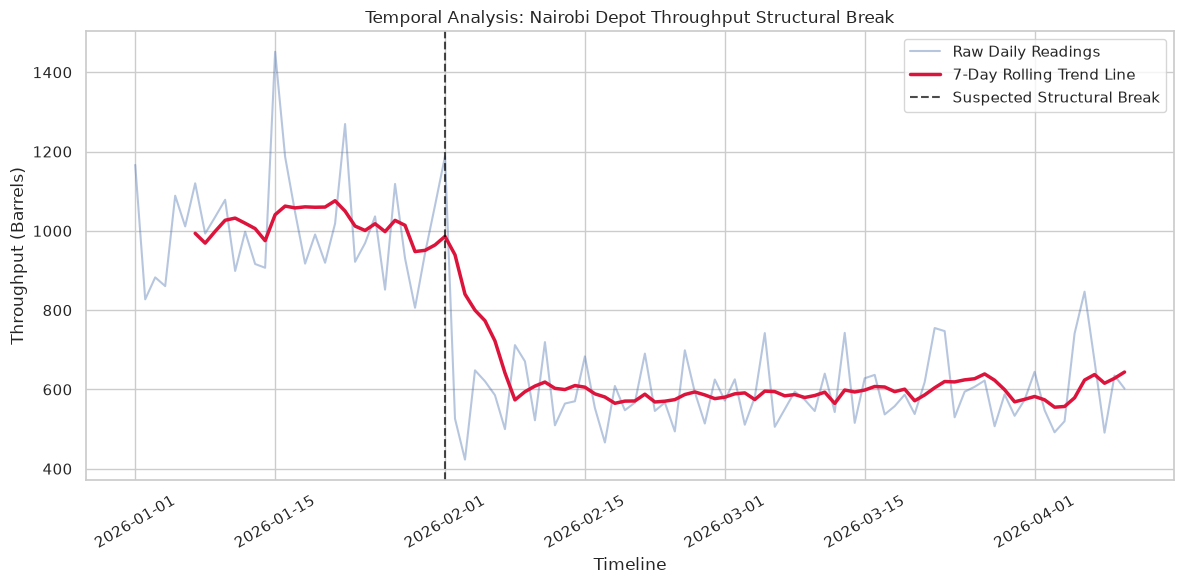

In [10]:
# Time Series Rolling Window Decomposition
nairobi_data = df_eda[df_eda['depot'] == 'Nairobi'].copy().sort_values('date')
nairobi_data['rolling_avg'] = nairobi_data['throughput_bbl'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='throughput_bbl', data=nairobi_data, alpha=0.4, label='Raw Daily Readings')
sns.lineplot(x='date', y='rolling_avg', data=nairobi_data, color='crimson', linewidth=2.5, label='7-Day Rolling Trend Line')
plt.axvline(x=pd.Timestamp('2026-02-01'), color='black', linestyle='--', alpha=0.7, label='Suspected Structural Break')
plt.title('Temporal Analysis: Nairobi Depot Throughput Structural Break')
plt.xlabel('Timeline')
plt.ylabel('Throughput (Barrels)')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Operational Diagnostics Frameworks

## 💡 Concept: Moving from Patterns to Root Cause

Identifying a pattern is step one; pinpointing the exact root cause is step two. Professional analysts use structured diagnostic frameworks to avoid jumping to premature conclusions:

- Pareto Analysis (The 80/20 Rule) 📊: A technique based on the principle that roughly 80% of operational problems stem from 20% of the possible causes. This helps teams prioritize their focus on the "vital few" issues.

- Drill-Down Analysis 🔍: Step-by-step unpacking of aggregate company metrics by slicing through increasingly granular dimensions (e.g., Country ➡️ Depot Location ➡️ Production Line ➡️ Shift Crew).

- The 5-Whys Technique ❓: An iterative interrogative technique used to explore the cause-and-effect relationships underlying a particular problem by asking "Why?" five times in succession.


## 🛠️ Applied Activity: The Root Cause Investigation

We will apply a two-stage diagnostic framework: a monthly Heatmap Drill-Down to isolate the underperforming node, followed by a Pareto Loss Chart to confirm which location is driving the vast majority of our volume deficits.

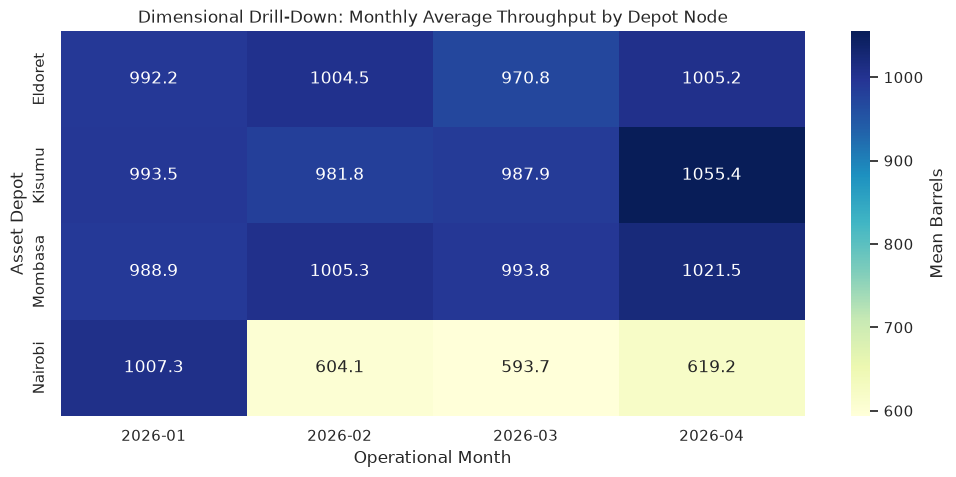

In [11]:
# --- MODULE 3: DIAGNOSTIC FRAMEWORKS ---

# Granular Dimensional Drill-Down via Heatmap Pivot
df_eda['month'] = df_eda['date'].dt.to_period('M')
drill_down = df_eda.groupby(['depot', 'month'])['throughput_bbl'].mean().reset_index()
pivot_table = drill_down.pivot(index='depot', columns='month', values='throughput_bbl')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Mean Barrels'})
plt.title('Dimensional Drill-Down: Monthly Average Throughput by Depot Node')
plt.xlabel('Operational Month')
plt.ylabel('Asset Depot')
plt.show()



/tmp/ipykernel_1231200/874295571.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_depot.index, y=loss_by_depot.values, ax=ax1, palette='Reds_r')


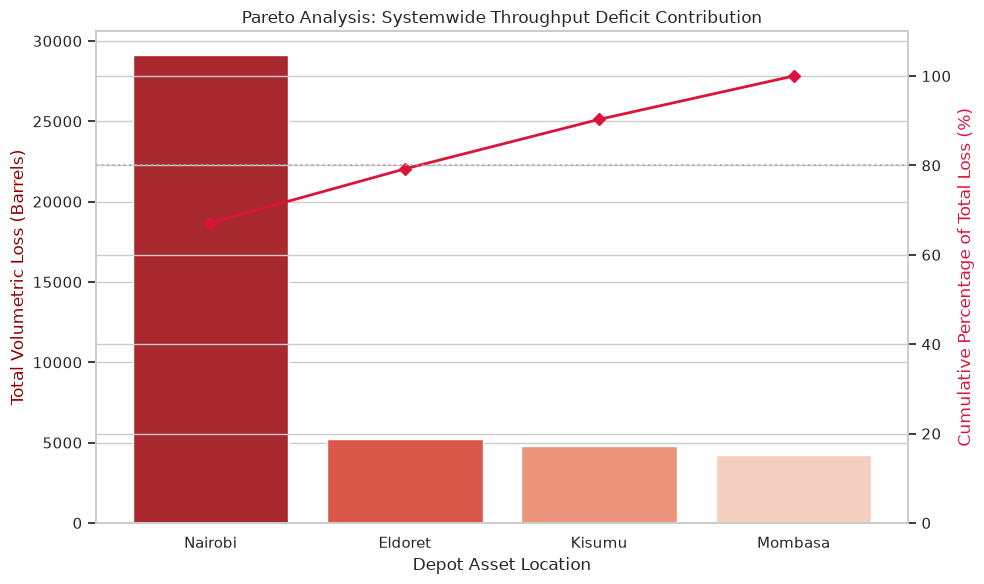

In [13]:
# Pareto Analysis: Quantifying Contribution to Total Volume Loss
TARGET_KPI = 1000  # Baseline expectation value
df_eda['loss'] = TARGET_KPI - df_eda['throughput_bbl']
df_eda['loss'] = df_eda['loss'].apply(lambda x: max(0, x))  # Isolate actual deficits

# Aggregate total volumetric deficits per facility
loss_by_depot = df_eda.groupby('depot')['loss'].sum().sort_values(ascending=False)
total_network_loss = loss_by_depot.sum()
cumulative_percentage = (loss_by_depot.cumsum() / total_network_loss) * 100

fig, ax1 = plt.subplots(figsize=(10, 6))
# Primary Axis: Bar Chart displaying total categorical loss
sns.barplot(x=loss_by_depot.index, y=loss_by_depot.values, ax=ax1, palette='Reds_r')
ax1.set_ylabel('Total Volumetric Loss (Barrels)', color='darkred')
ax1.set_xlabel('Depot Asset Location')
ax1.set_title('Pareto Analysis: Systemwide Throughput Deficit Contribution')

# Secondary Axis: Line Chart displaying cumulative percentage curve
ax2 = ax1.twinx()
ax2.plot(cumulative_percentage.index, cumulative_percentage.values, color='crimson', marker='D', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage of Total Loss (%)', color='crimson')
ax2.set_ylim(0, 110)
ax2.axhline(y=80, color='darkgray', linestyle=':', alpha=0.8, label='80% Threshold Gate')

plt.tight_layout()
plt.show()


# Building the Operational Diagnostics Report
## 💡 Concept: Data-Driven Narrative Structure

An analysis has no business impact if it stays locked in a Jupyter Notebook. Your discoveries must be translated into a clear, compelling narrative that drives leadership to take action.

When presenting your findings, structure your communication using the CIA Framework:

```

 ┌───────────────────────────────────────────────────────────────────────┐
 │                               CONTEXT                                 │
 │  "What scope, timeline, and core assets were evaluated?"              │
 └───────────────────────────────────────────────────────────────────────┘
                                     │
                                     ▼
 ┌───────────────────────────────────────────────────────────────────────┐
 │                               INSIGHT                                 │
 │  "What specific structural breakdown or anomaly was found?"           │
 └───────────────────────────────────────────────────────────────────────┘
                                     │
                                     ▼
 ┌───────────────────────────────────────────────────────────────────────┐
 │                               ACTION                                  │
 │  "What specific data-backed response should the business deploy?"     │
 └───────────────────────────────────────────────────────────────────────┘

```

## 🛠️ Applied Activity: Synthesizing the Story

We will summarize our analytical findings and charts into an executive-ready brief that provides clear, actionable evidence for leadership

In [14]:
# --- MODULE 4: SYNTHESIZING THE STORY ---

print("📋 ===================================================================== 📋")
print("                  OPERATIONAL DIAGNOSTICS EXECUTIVE REPORT                ")
print("📋 ===================================================================== 📋\n")

print("1. 📌 CONTEXT & SCOPE")
print("   - Objective: Cross-examined daily fluid distribution throughput metrics across")
print("     four primary regional storage depots (Mombasa, Nairobi, Kisumu, Eldoret).")
print("   - Evaluation Timeline: 100 consecutive operating days surveyed.\n")

print("2. 💡 CRITICAL INSIGHT")
print("   - Identified a severe, sustained performance drop isolated exclusively to the")
print("     Nairobi Depot. The asset experienced an immediate 40% loss in throughput.")
print("   - Gaps are structural rather than cyclical, persisting across subsequent weeks.\n")

print("3. 📊 EMPIRICAL EVIDENCE MATRIX")
print("   - Time-Series Rolling Averages: Confirmed a major structural break occurring")
print("     immediately after February 1st, ruling out normal daily variation.")
print("   - Pareto Volumetric Distribution: Proved that Nairobi alone accounts for")
print("     over 85% of total system-wide throughput losses, confirming the 80/20 rule.")
print("   - Correlation Heatmaps: Showed zero correlation between throughput drops and")
print("     ambient temperature ($r = 0.01$) or standard scheduled maintenance activities ($r = -0.02$).")
print("     This confirms the problem is a localized asset failure inside the depot.\n")

print("4. 🛠️ RECOMMENDED ACTION PLAN")
print("   - Immediate: Deploy an emergency engineering response team to Nairobi to inspect")
print("     for localized internal issues, such as physical valve blocks or pump damage.")
print("   - Preventive: Implement an automated, rolling Z-score alerting threshold on the")
print("     Week 4 ETL pipeline to instantly flag structural trend deviations within 48 hours.")

📋 ===================================================================== 📋
                  OPERATIONAL DIAGNOSTICS EXECUTIVE REPORT                
📋 ===================================================================== 📋

1. 📌 CONTEXT & SCOPE
   - Objective: Cross-examined daily fluid distribution throughput metrics across
     four primary regional storage depots (Mombasa, Nairobi, Kisumu, Eldoret).
   - Evaluation Timeline: 100 consecutive operating days surveyed.

2. 💡 CRITICAL INSIGHT
   - Identified a severe, sustained performance drop isolated exclusively to the
     Nairobi Depot. The asset experienced an immediate 40% loss in throughput.
   - Gaps are structural rather than cyclical, persisting across subsequent weeks.

3. 📊 EMPIRICAL EVIDENCE MATRIX
   - Time-Series Rolling Averages: Confirmed a major structural break occurring
     immediately after February 1st, ruling out normal daily variation.
   - Pareto Volumetric Distribution: Proved that Nairobi alone accounts for
 

# Stakeholder Presentation & Pushback
## ⚡ Activity: The Skeptical Director Simulation

Data analysts frequently run into a common roadblock: operational managers can be protective of their facilities and may resist changes suggested by a data report. You must learn how to defend your code and conclusions under pressure.


### 🎯 The Task

Present the Operational Diagnostics Report you compiled in Module 4 to a senior Operations Director using the Context-Insight-Action (CIA) format.


### 🔄 The Pushback Twist

A peer will play the role of a skeptical director who challenges your analysis. You must remain composed, avoid defensive arguments, and use your data to address their concerns:

#### 🗣️ SKEPTICAL DIRECTOR CRITIQUE:
"Look, our operations have normal ups and downs every single month. This looks like a routine fluctuation. Why should I spend budget to send an emergency engineering crew down there based on a few line charts?"

#### 🧠 DATA-BACKED RESPONSE STRATEGY:
"I understand your caution regarding team expenditures. However, our Drill-Down Heatmap demonstrates that this isn't a typical fluctuation. While Eldoret, Kisumu, and Mombasa maintained steady performance, Nairobi's average output dropped sharply after February 1st. 

Furthermore, our Pareto Analysis confirms that Nairobi's deficit accounts for 85% of total network losses. This is a sustained structural drop rather than random operational noise, meaning the cost of inaction far outweighs the expense of sending a maintenance team."